Composition of the fuel from Darwin code version 2.3 used for calculations, corresponding to a burnup of 13.4 % FIMA, from Samuelsson, K., Dumas, J. C., Sundman, B., Lamontagne, J., & Guéneau, C. (2020). Simulation of the chemical state of high burnup (U,Pu)O2 fuel in fast reactors based on thermodynamic calculations. Journal of Nuclear Materials, 532(1), 151969. https://doi.org/10.1016/j.jnucmat.2019.151969)

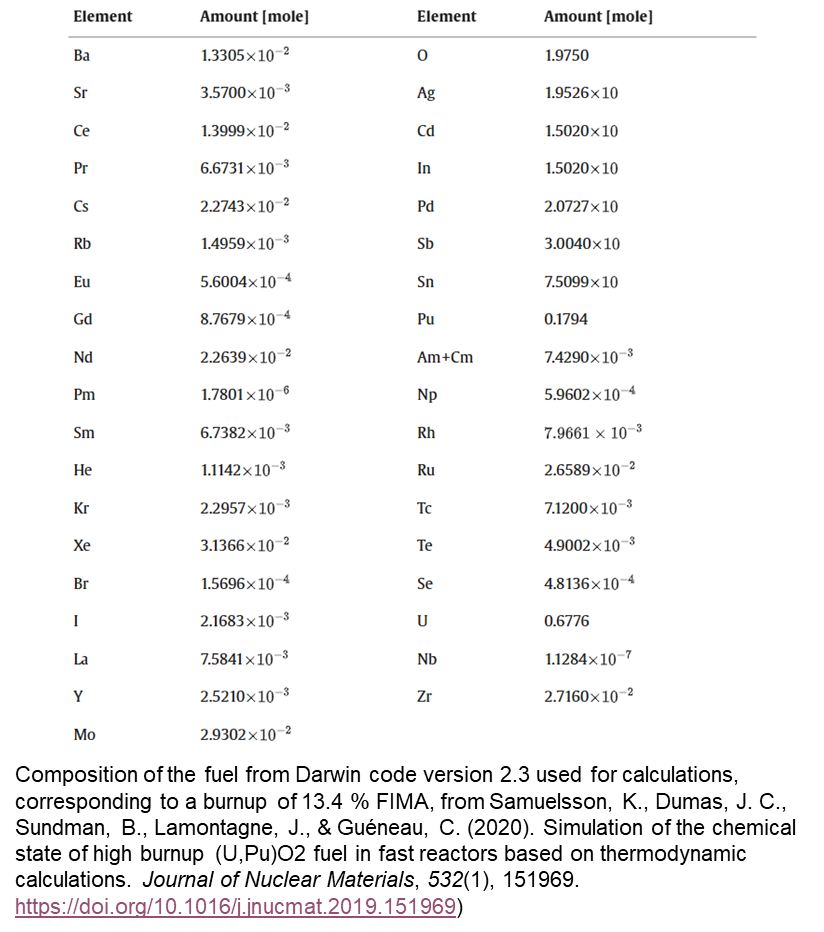

In [1]:
# Data from qevolution image (Samuelsson et al., 2020) at 13.4% FIMA

import pandas as pd
from pathlib import Path

# Explicit values (readable in the image)
element_moles = {
    "Ba": 1.3305e-2,
    "Sr": 3.5700e-3,
    "Ce": 1.3999e-2,
    "Pr": 6.6731e-3,
    "Cs": 2.2743e-2,
    "Rb": 1.4959e-3,
    "Eu": 5.6004e-4,
    "Gd": 8.7679e-4,
    "Nd": 2.2639e-2,
    "Pm": 1.7801e-6,
    "Sm": 6.7382e-3,
    "He": 1.1142e-3,
    "Kr": 2.2957e-3,
    "Xe": 3.1366e-2,
    "Br": 1.5696e-4,
    "I": 2.1683e-3,
    "La": 7.5841e-3,
    "Y": 2.5210e-3,
    "Mo": 2.9302e-2,
    "O": 1.9750,
    "Pu": 0.1794,
    "Am+Cm": 7.4290e-3,
    "Np": 5.9602e-4,
    "Rh": 7.9661e-3,
    "Ru": 2.6589e-2,
    "Tc": 7.1200e-3,
    "Te": 4.9002e-3,
    "Se": 4.8136e-4,
    "U": 0.6776,
    "Nb": 1.1284e-7,
    "Zr": 2.7160e-2,
}

In [2]:
# Fission normalization
# Given: 13.4% fissions per initial heavy-metal atom (U+Pu)

hm_final_moles = element_moles["U"] + element_moles["Pu"]
FIMA = 0.134
hm_initial_moles = hm_final_moles / (1 - FIMA)
q_initial = 0.22
q_final = element_moles["Pu"] / hm_final_moles
print(f"Initial moles (U+Pu): {hm_initial_moles:.4f}, Final moles (U+Pu): {hm_final_moles:.4f}")
print(f"Initial Pu fraction: {q_initial:.4f}, Final Pu fraction: {q_final:.4f}")
fission_moles = FIMA * hm_initial_moles
Pu_fission_fraction = (element_moles["Pu"] - q_initial * hm_initial_moles) / fission_moles
print(f"Pu fission fraction: {Pu_fission_fraction:.4f}")
u_fission_fraction = (element_moles["U"] - (1 - q_initial) * hm_initial_moles) / fission_moles
print(f"U fission fraction: {u_fission_fraction:.4f}")
rows = []
for el, mol in sorted(element_moles.items()):
    yield_per_fission = mol / fission_moles
    rows.append({
        "element": el,
        "moles": mol,
        "yield_per_fission": yield_per_fission,
        "yield_percent": 100.0 * yield_per_fission
    })

yield_df = pd.DataFrame(rows).sort_values("yield_per_fission", ascending=False).reset_index(drop=True)


o_over_m = element_moles["O"] /(element_moles["U"] + element_moles["Pu"])
print(o_over_m)


Initial moles (U+Pu): 0.9896, Final moles (U+Pu): 0.8570
Initial Pu fraction: 0.2200, Final Pu fraction: 0.2093
Pu fission fraction: -0.2889
U fission fraction: -0.7111
2.3045507584597433


In [3]:
# Print and save
pd.set_option("display.float_format", lambda x: f"{x:.6e}")

print("\n=== Element yields (all elements) ===")
print(yield_df.to_string(index=False))



=== Element yields (all elements) ===
element        moles  yield_per_fission  yield_percent
      O 1.975000e+00       1.489359e+01   1.489359e+03
      U 6.776000e-01       5.109821e+00   5.109821e+02
     Pu 1.794000e-01       1.352866e+00   1.352866e+02
     Xe 3.136600e-02       2.365328e-01   2.365328e+01
     Mo 2.930200e-02       2.209681e-01   2.209681e+01
     Zr 2.716000e-02       2.048151e-01   2.048151e+01
     Ru 2.658900e-02       2.005092e-01   2.005092e+01
     Cs 2.274300e-02       1.715063e-01   1.715063e+01
     Nd 2.263900e-02       1.707220e-01   1.707220e+01
     Ce 1.399900e-02       1.055673e-01   1.055673e+01
     Ba 1.330500e-02       1.003338e-01   1.003338e+01
     Rh 7.966100e-03       6.007282e-02   6.007282e+00
     La 7.584100e-03       5.719214e-02   5.719214e+00
  Am+Cm 7.429000e-03       5.602252e-02   5.602252e+00
     Tc 7.120000e-03       5.369233e-02   5.369233e+00
     Sm 6.738200e-03       5.081316e-02   5.081316e+00
     Pr 6.673100e-03      